<a href="https://colab.research.google.com/github/amoid3203-3009/parkinsons-detection-project/blob/main/src/models/train_lstm_skeleton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 Initializing LSTM Model Skeleton...
📊 Generating Mock Data for testing the architecture...
Data Shape: (1000, 50, 2)
🧠 Building the Neural Network...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,217 (67.25 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 0 (0.00 B)


⚡ Starting Training Phase...
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5150 - loss: 0.6943 - val_accuracy: 0.4150 - val_loss: 0.7052
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5320 - loss: 0.6929 - val_accuracy: 0.4150 - val_loss: 0.7038
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.4150 - val_loss: 0.7010
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5360 - loss: 0.6929 - val_accuracy: 0.4150 - val_loss: 0.7049
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5260 - loss: 0.6923 - val_accuracy: 0.4150 - val_loss: 0.7059
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5330 - loss: 0.6917 - val_accuracy: 0.4150 - val_loss: 0.7082
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5340 - loss: 0.6914 - val_accuracy: 0.4150 - val_loss: 0.7086
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5330 - loss: 0.6

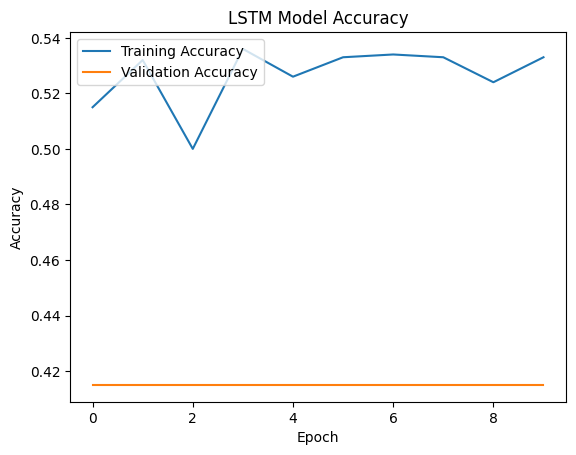

✅ Skeleton Test Complete! Ready for real data.


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# ==========================================
# 1. SETTINGS & HYPERPARAMETERS
# ==========================================
TIME_STEPS = 50      # How many finger taps we look at in one sequence
FEATURES = 2         # e.g., Left Key, Right Key
BATCH_SIZE = 32
EPOCHS = 10          # Number of times the AI looks at the data

print("🚀 Initializing LSTM Model Skeleton...")

# ==========================================
# 2. DATA LOADING (Mock Data for now)
# ==========================================
# TODO: Once Toufiqe gives you 'cleaned_data.csv', you will load it using pandas:
# df = pd.read_csv('../../data/cleaned_data.csv')
# X_train, y_train = your_preprocessing_function(df)

print("📊 Generating Mock Data for testing the architecture...")
# Creating fake 3D data: (Samples, Time Steps, Features)
X_train = np.random.random((1000, TIME_STEPS, FEATURES))
# Creating fake labels: 0 = Healthy, 1 = Parkinson's
y_train = np.random.randint(2, size=(1000, 1))

# Create fake validation data (to test accuracy)
X_val = np.random.random((200, TIME_STEPS, FEATURES))
y_val = np.random.randint(2, size=(200, 1))

print(f"Data Shape: {X_train.shape}")

# ==========================================
# 3. BUILD THE LSTM ARCHITECTURE
# ==========================================
print("🧠 Building the Neural Network...")
model = Sequential()

# The LSTM Layer (The 'Memory' block for time-series data)
model.add(LSTM(units=64, input_shape=(TIME_STEPS, FEATURES), return_sequences=False))

# Dropout Layer (Prevents the model from memorizing the data / overfitting)
model.add(Dropout(0.3))

# Output Layer (Binary classification: 1 neuron, sigmoid activation)
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Show a summary of the network in the terminal
model.summary()

# ==========================================
# 4. TRAIN THE MODEL
# ==========================================
print("\n⚡ Starting Training Phase...")
history = model.fit(X_train, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val, y_val))

# ==========================================
# 5. GENERATE EVALUATION GRAPHS (For your report)
# ==========================================
print("\n📈 Generating Performance Graphs...")

# Plot Training & Validation Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show() # This will pop up a window with the graph for your presentation!

print("✅ Skeleton Test Complete! Ready for real data.")